In [1]:
from tiffany_rf import evaluate_forest, evaluate_forest_classes
from sklearn import datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


%load_ext autoreload
%autoreload 2

In [2]:
parkinsons_df = pd.read_csv("../res/parkinsons.csv")
credit_df = pd.read_csv("../res/credit_approval.csv")
rice_df = pd.read_csv("../res/rice.csv")
digits = datasets.load_digits(return_X_y=True)
digits_dataset_X = digits[0]
digits_dataset_y = digits[1]
N = len(digits_dataset_X)
digits_df = pd.DataFrame(digits_dataset_X)
digits_df['label'] = digits_dataset_y

In [3]:
ntrees = [1, 5, 10, 20, 30, 40, 50]

In [4]:
parkinsons_metrics = evaluate_forest(parkinsons_df, ntrees, 'Diagnosis', max_depth=10)
credit_metrics = evaluate_forest(credit_df, ntrees, 'label', max_depth=10)

Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees
Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees


In [5]:
parkinsons_metrics

{1: (np.float64(0.8055555555555556),
  np.float64(0.8362931839402427),
  np.float64(0.9357142857142857),
  np.float64(0.8816098575136395)),
 5: (np.float64(0.7944444444444443),
  np.float64(0.8437085218702866),
  np.float64(0.9071428571428573),
  np.float64(0.8723194495941993)),
 10: (np.float64(0.8166666666666668),
  np.float64(0.8534809308338719),
  np.float64(0.9285714285714286),
  np.float64(0.8875427135382644)),
 20: (np.float64(0.8333333333333333),
  np.float64(0.8537535014005602),
  np.float64(0.95),
  np.float64(0.8985433550505852)),
 30: (np.float64(0.85),
  np.float64(0.8617296918767506),
  np.float64(0.9642857142857142),
  np.float64(0.9093643731129829)),
 40: (np.float64(0.8388888888888889),
  np.float64(0.8547934173669468),
  np.float64(0.9571428571428573),
  np.float64(0.9024900683298904)),
 50: (np.float64(0.8499999999999999),
  np.float64(0.8727278603749191),
  np.float64(0.95),
  np.float64(0.9081218991118881))}

In [6]:
credit_metrics

{1: (np.float64(0.6997271825396825),
  np.float64(0.7023031465550648),
  np.float64(0.6030788177339902),
  np.float64(0.6420650854069637)),
 5: (np.float64(0.775),
  np.float64(0.8396076482856669),
  np.float64(0.6379310344827587),
  np.float64(0.7137761969788955)),
 10: (np.float64(0.7729662698412698),
  np.float64(0.8930467720685111),
  np.float64(0.5669950738916256),
  np.float64(0.6843578790411767)),
 20: (np.float64(0.7984375),
  np.float64(0.878624390812113),
  np.float64(0.6482758620689654),
  np.float64(0.7414171724115027)),
 30: (np.float64(0.81875),
  np.float64(0.8897008854354393),
  np.float64(0.6862068965517242),
  np.float64(0.770472767972768)),
 40: (np.float64(0.83125),
  np.float64(0.9055402244814011),
  np.float64(0.703448275862069),
  np.float64(0.7893515378657491)),
 50: (np.float64(0.8265625),
  np.float64(0.9255095710290219),
  np.float64(0.6758620689655173),
  np.float64(0.7762067442361559))}

In [28]:
def plot_metrics(ntree_to_metrics, dataset_name):
    data = pd.DataFrame.from_dict(
        ntree_to_metrics,
        orient='index',
        columns=['accuracy', 'precision', 'recall', 'f1']
    )
    
    p = sns.lineplot(data)
    plt.xlabel("ntrees")
    plt.title(f"{dataset_name} dataset")
    plt.legend(title="Metrics")
    plt.show()
    p.get_figure().savefig(f"../rf_figures/{dataset_name}_all.png")

    sns.set_theme()
    sns.lineplot(x=data.index, y='accuracy', data=data)
    sns.lineplot(x=data.index, y='f1', data=data)
    plt.xlabel('ntree')
    plt.title(f"{dataset_name}: Ntree vs Accuracy and F1 Score")
    plt.legend(['Accuracy', 'F1 Score'])
    plt.show()
    plt.savefig(f"../rf_figures/{dataset_name}.png")

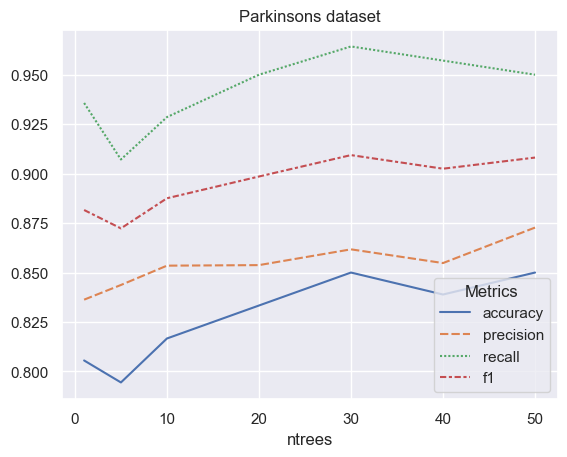

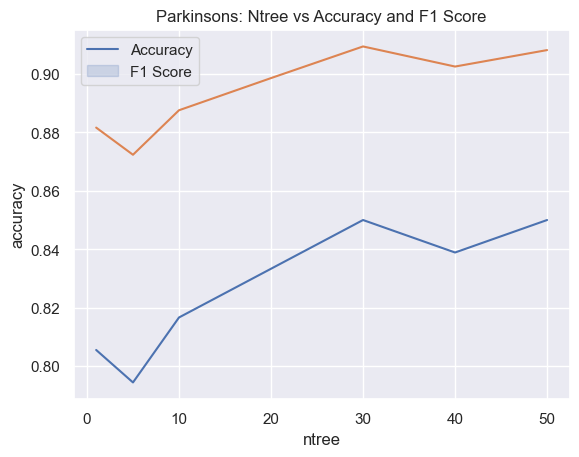

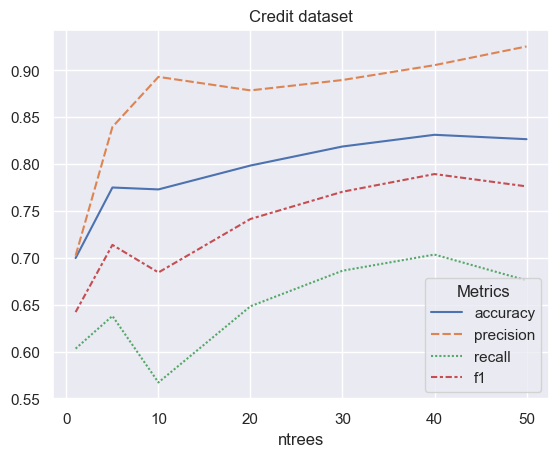

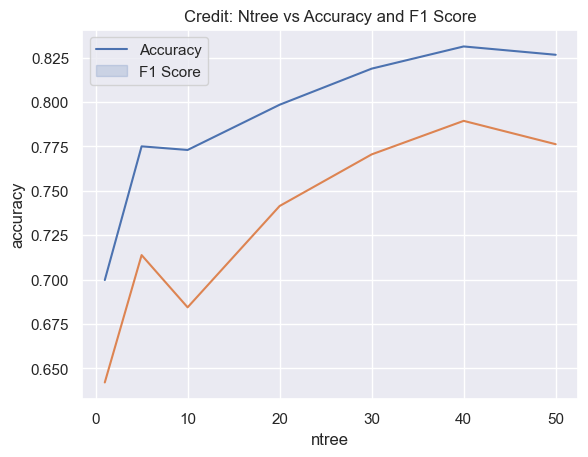

<Figure size 640x480 with 0 Axes>

In [29]:
datasets = ["Parkinsons", "Credit"]
for d in datasets:
    plot_metrics(eval(f"{d.lower()}_metrics"), d)

In [10]:
rice_df['label'].value_counts()

label
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

In [30]:
ntrees = [1, 5, 10, 20, 30, 40, 50]
rice_metrics_classes = evaluate_forest_classes(rice_df, ntrees, 'label', pos_class='Cammeo', neg_class='Osmancik', max_depth=10)

Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees


In [31]:
rice_metrics_classes

{1: (np.float64(0.8637795275590552),
  np.float64(0.8533294783168438),
  np.float64(0.8386503067484663),
  np.float64(0.8392287519782695)),
 5: (np.float64(0.8855643044619423),
  np.float64(0.8669797916378732),
  np.float64(0.8711656441717791),
  np.float64(0.8665082082869932)),
 10: (np.float64(0.9039370078740158),
  np.float64(0.8890672071477672),
  np.float64(0.8883435582822086),
  np.float64(0.8880868167656054)),
 20: (np.float64(0.9083989501312336),
  np.float64(0.9112519805751547),
  np.float64(0.8723926380368099),
  np.float64(0.8907611158969762)),
 30: (np.float64(0.8979002624671916),
  np.float64(0.884939842815822),
  np.float64(0.8773006134969326),
  np.float64(0.8803133583751137)),
 40: (np.float64(0.909186351706037),
  np.float64(0.9038946920774855),
  np.float64(0.8834355828220859),
  np.float64(0.8927406034873535)),
 50: (np.float64(0.9128608923884516),
  np.float64(0.9159755143130728),
  np.float64(0.877914110429448),
  np.float64(0.8962050654876558))}

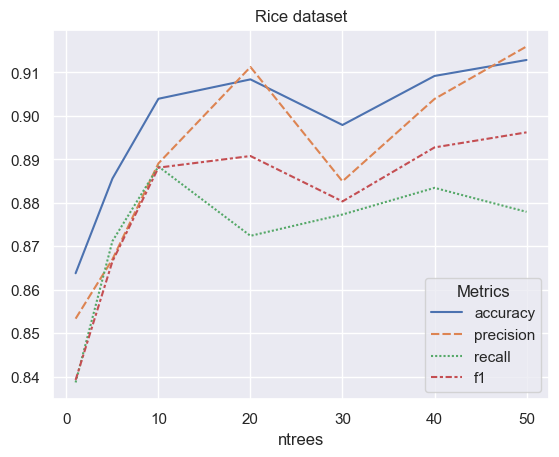

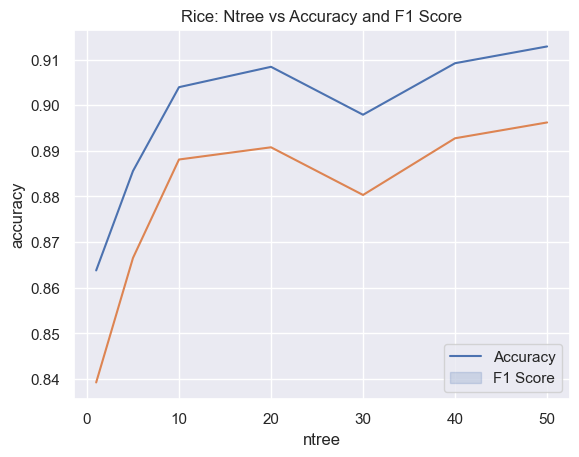

<Figure size 640x480 with 0 Axes>

In [32]:
plot_metrics(eval(f"rice_metrics_classes"), "Rice")

In [33]:
digits_metrics = evaluate_forest(digits_df, ntrees, 'label', max_depth=10)

Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees


In [36]:
digits_metrics

{1: (np.float64(0.9682234432234431),
  np.float64(0.9547368421052631),
  np.float64(0.9800000000000001),
  np.float64(0.9627379103241172)),
 5: (np.float64(0.9693858255204194),
  np.float64(1.0),
  np.float64(0.9343315018315019),
  np.float64(0.9652943427276262)),
 10: (np.float64(0.993426724137931),
  np.float64(1.0),
  np.float64(0.9850000000000001),
  np.float64(0.9922038980509745)),
 20: (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)),
 30: (np.float64(0.9967741935483871),
  np.float64(1.0),
  np.float64(0.9933333333333334),
  np.float64(0.9965517241379309)),
 40: (np.float64(0.9970588235294118),
  np.float64(1.0),
  np.float64(0.9941176470588236),
  np.float64(0.9969696969696968)),
 50: (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0))}

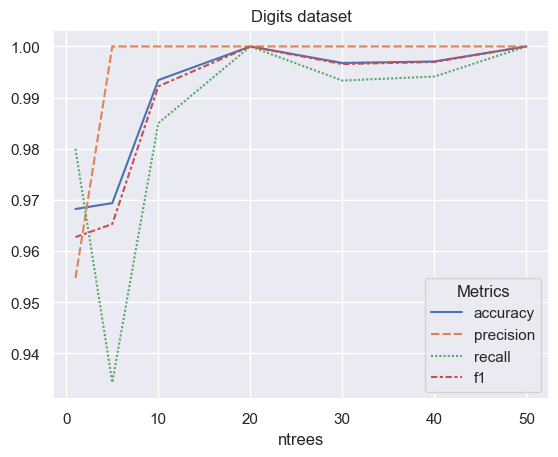

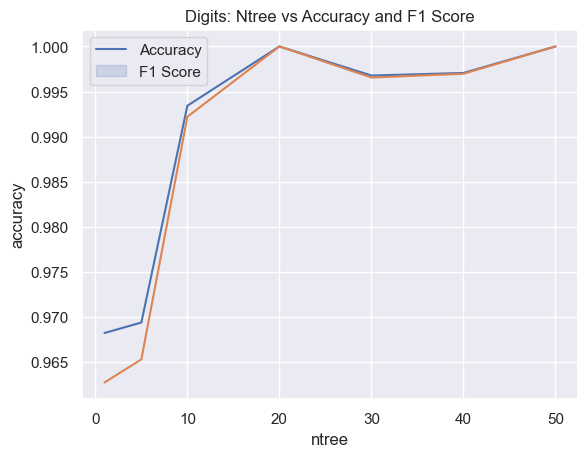

<Figure size 640x480 with 0 Axes>

In [37]:
plot_metrics(eval(f"digits_metrics"), "Digits")